In [3]:
# Run this first - installs any missing libraries
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'matplotlib', 
                'seaborn', 'scikit-learn', 'plotly'], 
                capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [5]:
# Load the dataset (make sure the CSV is in the same folder)
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Customers: {len(df)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (7043, 21)
Total Customers: 7043

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("=== DATASET INFO ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nChurn Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")
print(f"\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== DATASET INFO ===
Rows: 7043, Columns: 21

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%

Missing Values:
Series([], dtype: int64)


In [7]:
# Fix TotalCharges column (has spaces instead of numbers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID (not needed for analysis)
df_clean = df.drop('customerID', axis=1)

print("✅ Data cleaned!")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

✅ Data cleaned!
Missing values remaining: 0


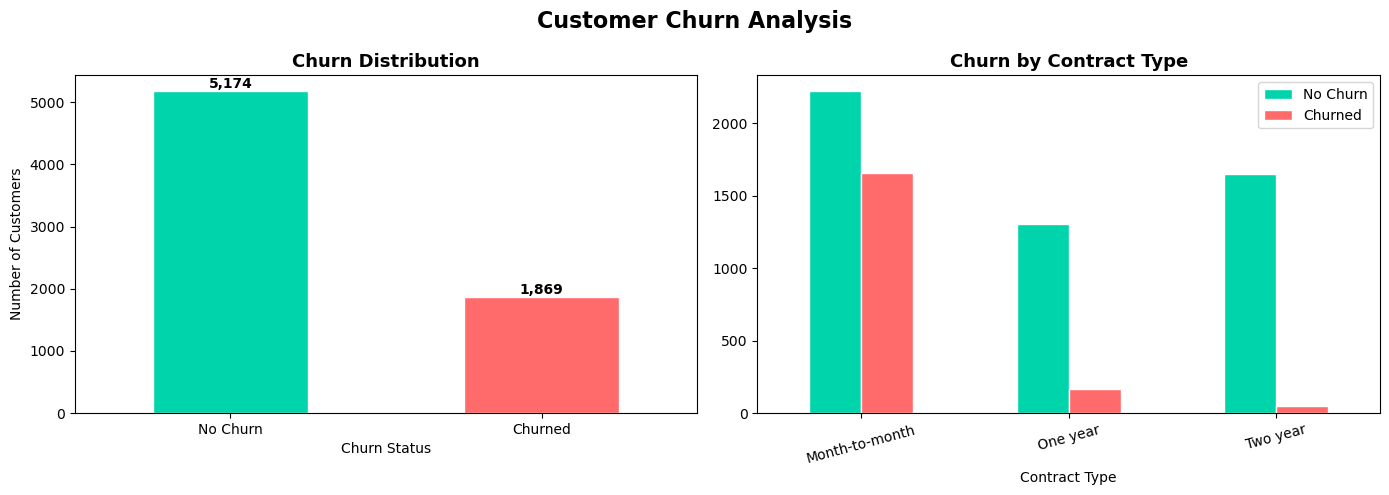

✅ Chart saved as churn_overview.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Churn Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Churn Count
colors = ['#00d4aa', '#ff6b6b']
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], 
                                 color=colors, edgecolor='white')
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['No Churn', 'Churned'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x()+p.get_width()/2, p.get_height()+50),
                     ha='center', fontweight='bold')

# Chart 2 - Churn by Contract Type
ct = df.groupby(['Contract','Churn']).size().unstack()
ct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Churn by Contract Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(['No Churn', 'Churned'])

plt.tight_layout()
plt.savefig('churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as churn_overview.png")

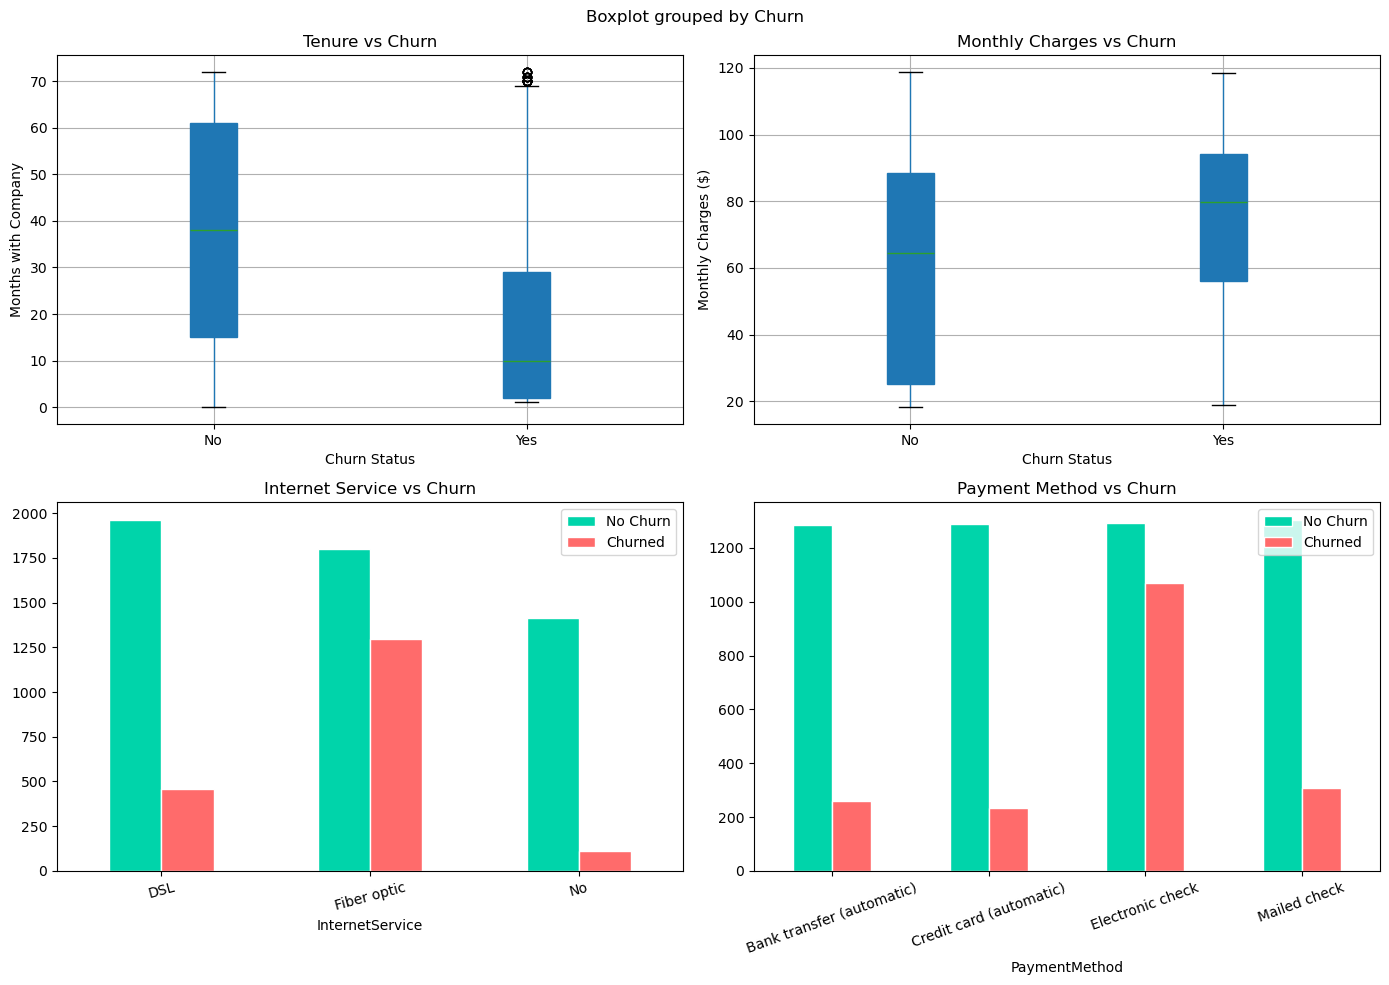

✅ Chart saved!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Churn Drivers', fontsize=16, fontweight='bold')

# Chart 1 - Tenure vs Churn
df.boxplot(column='tenure', by='Churn', ax=axes[0,0], 
           patch_artist=True)
axes[0,0].set_title('Tenure vs Churn')
axes[0,0].set_xlabel('Churn Status')
axes[0,0].set_ylabel('Months with Company')

# Chart 2 - Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0,1],
           patch_artist=True)
axes[0,1].set_title('Monthly Charges vs Churn')
axes[0,1].set_xlabel('Churn Status')
axes[0,1].set_ylabel('Monthly Charges ($)')

# Chart 3 - Internet Service vs Churn
internet_churn = df.groupby(['InternetService','Churn']).size().unstack(fill_value=0)
internet_churn.plot(kind='bar', ax=axes[1,0], color=colors, edgecolor='white')
axes[1,0].set_title('Internet Service vs Churn')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=15)
axes[1,0].legend(['No Churn','Churned'])

# Chart 4 - Payment Method vs Churn  
pay_churn = df.groupby(['PaymentMethod','Churn']).size().unstack(fill_value=0)
pay_churn.plot(kind='bar', ax=axes[1,1], color=colors, edgecolor='white')
axes[1,1].set_title('Payment Method vs Churn')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=20)
axes[1,1].legend(['No Churn','Churned'])

plt.tight_layout()
plt.savefig('churn_drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [16]:
# Encode categorical columns
df_model = df_clean.copy()
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Split data
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"✅ Model Accuracy: {accuracy:.1f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred, 
      target_names=['No Churn', 'Churned']))

✅ Model Accuracy: 79.6%

Detailed Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1036
     Churned       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



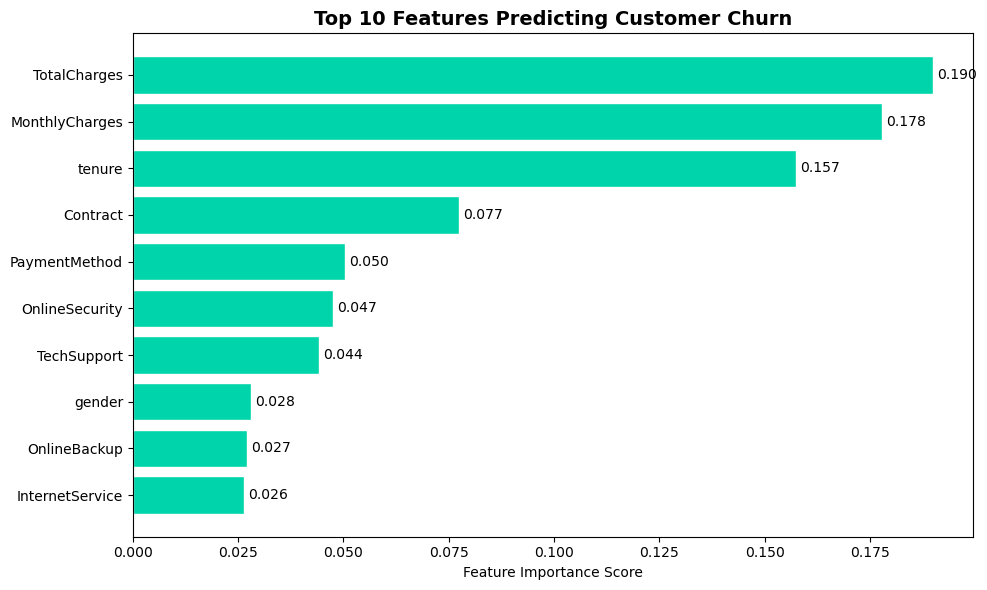

✅ Feature importance chart saved!


In [18]:
# What factors matter most for predicting churn?
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance'], 
                color='#00d4aa', edgecolor='white')
plt.title('Top 10 Features Predicting Customer Churn', 
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')

for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved!")

In [20]:
churn_rate = df['Churn'].value_counts(normalize=True)['Yes']*100
avg_monthly_churned = df[df['Churn']=='Yes']['MonthlyCharges'].mean()
avg_tenure_churned = df[df['Churn']=='Yes']['tenure'].mean()
top_contract_churn = df[df['Churn']=='Yes']['Contract'].value_counts().index[0]

print("=" * 55)
print("   CUSTOMER CHURN ANALYSIS - EXECUTIVE SUMMARY")
print("=" * 55)
print(f"\n📊 DATASET:  {len(df):,} customers analyzed")
print(f"🚨 CHURN RATE:  {churn_rate:.1f}% of customers churned")
print(f"💰 AVG MONTHLY CHARGE (churned): ${avg_monthly_churned:.2f}")
print(f"📅 AVG TENURE BEFORE CHURN: {avg_tenure_churned:.0f} months")
print(f"📄 HIGHEST CHURN CONTRACT: {top_contract_churn}")
print(f"🤖 MODEL ACCURACY: {accuracy:.1f}%")
print("\n📌 KEY FINDINGS:")
print("  1. Month-to-month contracts churn the most")
print("  2. Customers churning have higher monthly charges")
print("  3. New customers (low tenure) churn most")
print("  4. Fiber optic users have higher churn rate")
print("\n💡 RECOMMENDATIONS:")
print("  → Offer discounts to month-to-month customers")
print("  → Focus retention efforts on first 12 months")
print("  → Review pricing for fiber optic plans")
print("=" * 55)

   CUSTOMER CHURN ANALYSIS - EXECUTIVE SUMMARY

📊 DATASET:  7,043 customers analyzed
🚨 CHURN RATE:  26.5% of customers churned
💰 AVG MONTHLY CHARGE (churned): $74.44
📅 AVG TENURE BEFORE CHURN: 18 months
📄 HIGHEST CHURN CONTRACT: Month-to-month
🤖 MODEL ACCURACY: 79.6%

📌 KEY FINDINGS:
  1. Month-to-month contracts churn the most
  2. Customers churning have higher monthly charges
  3. New customers (low tenure) churn most
  4. Fiber optic users have higher churn rate

💡 RECOMMENDATIONS:
  → Offer discounts to month-to-month customers
  → Focus retention efforts on first 12 months
  → Review pricing for fiber optic plans
